# Pump Telemetry Presentation Workbook

## Helper Functions:

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from scipy.signal import savgol_filter
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

project_root = Path.cwd()
hidden_dir = project_root / 'Hidden'
if str(hidden_dir) not in sys.path:
    sys.path.insert(0, str(hidden_dir))

import presentation_emulator as _presentation_emulator
_presentation_emulator = importlib.reload(_presentation_emulator)

PresentationPumpTelemetryEmulator = getattr(
    _presentation_emulator,
    'PresentationPumpTelemetryEmulator',
    getattr(_presentation_emulator, 'PumpTelemetryEmulator')
)

if hasattr(_presentation_emulator, 'PresentationEmulatorConfig'):
    PresentationEmulatorConfig = _presentation_emulator.PresentationEmulatorConfig
elif hasattr(_presentation_emulator, 'PumpTelemetryEmulatorConfig'):
    PresentationEmulatorConfig = _presentation_emulator.PumpTelemetryEmulatorConfig
else:
    PresentationEmulatorConfig = None

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'legend.frameon': False,
    'font.size': 10,
    'grid.alpha': 0.25,
})

raw_features = ['raw_vibration']
engineered_features = ['vibration_rms', 'vibration_trend', 'pressure_reserve', 'motor_temp']
csv_path = project_root / 'presentation_pump_telemetry.csv'

# Regime boundary hours — used throughout for consistent plot annotations
NOMINAL_END_H   = 320.0
FAILURE_START_H = 360.0
TRAIN_CUTOFF_H  = 380.0

def add_regime_lines(ax, legend=True):
    """Add consistent nominal/failure/train-cutoff vertical markers to a time-axis plot."""
    ax.axvline(x=NOMINAL_END_H,   color='#e69f00', linestyle=':', linewidth=1.4, label='Nominal end (320 h)')
    ax.axvline(x=FAILURE_START_H, color='#cc3311', linestyle=':', linewidth=1.4, label='Failure onset (360 h)')
    ax.axvline(x=TRAIN_CUTOFF_H,  color='#444444', linestyle='-.', linewidth=1.2, label='Train cutoff (380 h)')
    if legend:
        ax.legend(loc='upper left')

def rolling_rms(signal, window=61):
    series = pd.Series(signal, dtype='float64')
    return series.rolling(window=window, min_periods=1, center=True).apply(lambda arr: float(np.sqrt(np.mean(np.square(arr)))), raw=True).bfill().ffill().to_numpy()

def rolling_trend(signal, window=31):
    values = np.asarray(signal, dtype=float)
    half_window = window // 2
    trend_values = []
    for index in range(values.size):
        start = max(0, index - half_window)
        stop = min(values.size, index + half_window + 1)
        window_values = values[start:stop]
        if window_values.size < 2:
            trend_values.append(np.nan)
        else:
            trend_values.append((window_values[-1] - window_values[0]) / max(1, window_values.size - 1))
    return pd.Series(trend_values).bfill().ffill().to_numpy()

def enforce_physical_limits(predictions, inputs):
    """Clip predictions to [0, 1] and apply domain rule: severe pressure deficit caps efficiency at 0.35."""
    bounded = np.clip(np.asarray(predictions, dtype=float), 0.0, 1.0)
    cavitation_mask = inputs['pressure_reserve'].to_numpy() < -8.0
    bounded = np.where(cavitation_mask, np.minimum(bounded, 0.35), bounded)
    return bounded

c:\Users\hp\OneDrive - University of Southampton\Year 3\2 DCE\DCE Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Emulator Generation

This emulator recreates the sensor data a real pump monitoring system would produce — including measurement noise, electrical interference, random transient bursts, sensor dropouts, and a slowly developing bearing fault that eventually drives the pump into a failure regime with a visible catastrophic step at hour 420.

The generated CSV contains only the **raw sensor readings** and the efficiency target. The engineered features (`calibrated_pressure`, `pressure_reserve`, `vibration_rms`, `vibration_trend`) are deliberately withheld from the file so that deriving them is a meaningful step in this notebook.

## Data Schema

Columns present in the raw CSV file:

| Column | Meaning | Unit |
|---|---|---|
| `timestamp` | Absolute sample time | ISO datetime |
| `time_hours` | Time since start of run | hours |
| `raw_vibration` | Noisy vibration sensor reading | relative amplitude (a.u.) |
| `drifted_pressure` | Measured pressure with sensor drift | kPa |
| `motor_temp` | Motor casing temperature | °C |
| `fluid_temp` | Process fluid temperature | °C |
| `pump_efficiency` | Target variable for the model | unitless |
| `suggested_split` | `"train"` (0–380 h) or `"test"` (380–500 h) | — |

Columns derived in this notebook (the feature engineering step):

| Column | How derived | Why |
|---|---|---|
| `calibrated_pressure` | `drifted_pressure` − drift correction | Removes known sensor offset |
| `pressure_reserve` | `calibrated_pressure` − rolling mean | Detects drops relative to local baseline |
| `vibration_rms` | Rolling RMS of cleaned vibration | Captures energy envelope of the signal |
| `vibration_trend` | Rolling slope of cleaned vibration | Detects whether vibration is rising or falling |

In [2]:
# Handle both emulator API variants: with or without a config class
if PresentationEmulatorConfig is None:
    emulator = PresentationPumpTelemetryEmulator()
else:
    emulator = PresentationPumpTelemetryEmulator(PresentationEmulatorConfig())
telemetry_df = emulator.generate(csv_path)
print(telemetry_df[['timestamp', 'time_hours', 'raw_vibration', 'drifted_pressure', 'motor_temp', 'pump_efficiency']].head())

Successfully compiled: c:\Users\hp\OneDrive - University of Southampton\Year 3\2 DCE\DCE Code\ML+AI_workshop\presentation_pump_telemetry.csv
Generated 30000 records across 500 hours.
Total corrupted telemetry dropout frames: 592

                    timestamp  time_hours  raw_vibration  drifted_pressure  motor_temp  fluid_temp  pump_efficiency suggested_split
2026-01-01 00:00:00.000000000    0.000000       0.051802        121.088404   59.615072   19.968517         0.417143           train
2026-01-01 00:01:00.000000001    0.016667       0.425747        120.804103   61.399733   20.049884         0.406499           train
2026-01-01 00:01:59.999999998    0.033333       1.061236        121.158068   60.537206   19.947039         0.407505           train
2026-01-01 00:03:00.000000000    0.050000       1.066267        121.008035   61.096086   20.086700         0.411444           train
2026-01-01 00:04:00.000000001    0.066667       0.328239        121.477393   59.825315   19.976471         0.4

## Cleaning the Telemetry

Three things go wrong with raw sensor data before we can learn from it:

1. **Sensor dropouts** — windows of readings go `NaN` due to communication faults. Forward-filling restores continuity without inventing new values.
2. **High-frequency noise** — the raw vibration signal is dominated by electrical hash and mechanical carrier frequencies. A Savitzky–Golay filter smooths the noise floor while preserving the structural peaks that indicate bearing state.
3. **Sensor drift** — the pressure transducer drifts at a known rate (−0.065 kPa/h). Subtracting the drift deterministically unlocks the pressure signal for use in the model.

These three steps are *engineering knowledge applied to data*, not statistics. The model cannot learn them from data alone — they require knowing how the sensor works.

**What to notice in the plots:** the vibration cleaning separates genuine structural bursts from the carrier noise; the pressure correction removes the downward slope, leaving a stable baseline the model can reason about.

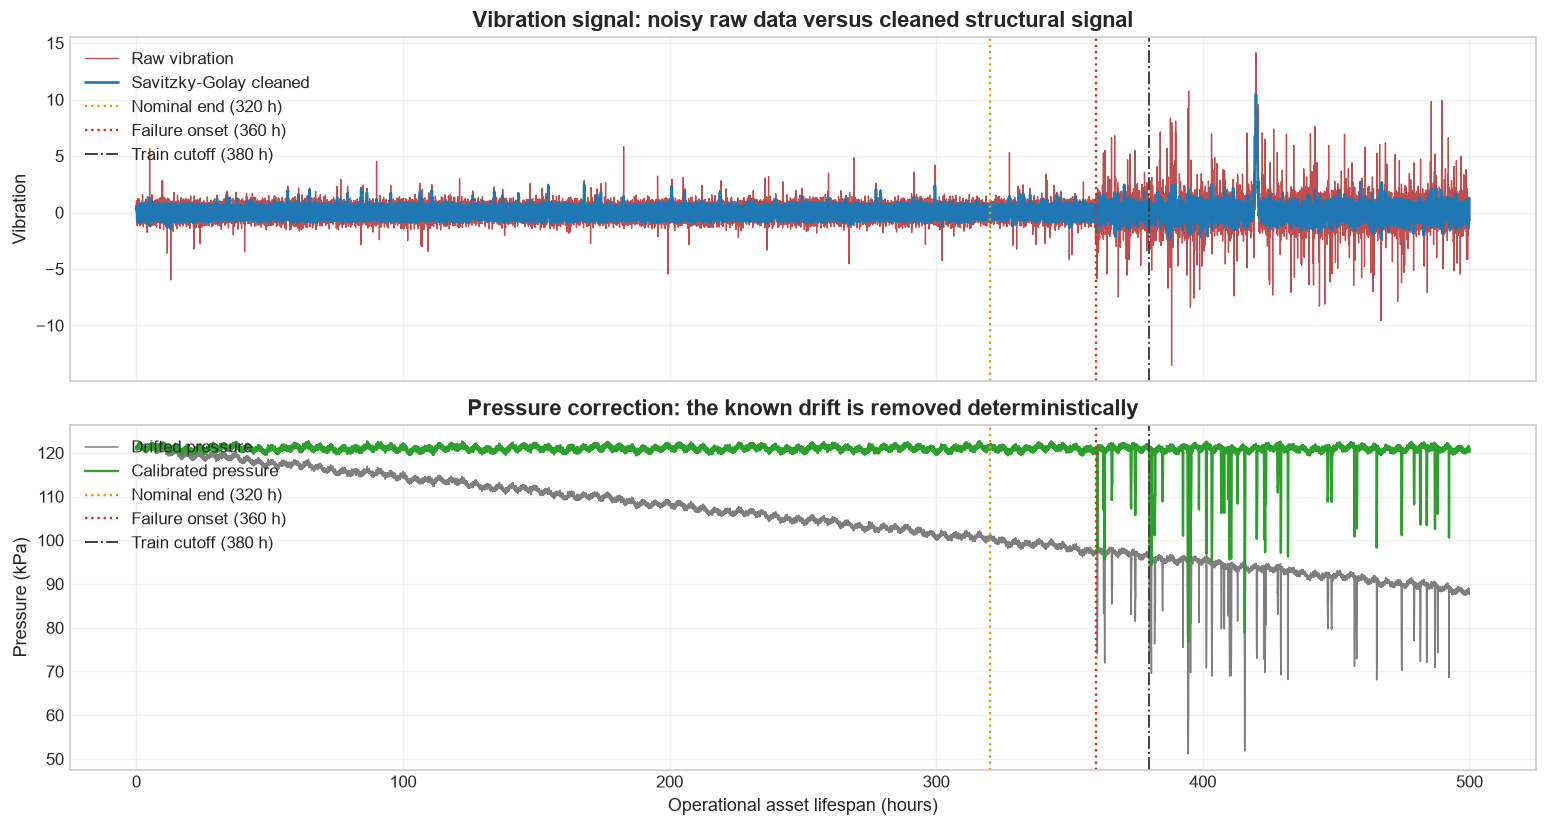

In [3]:
working_df = telemetry_df.copy()
sensor_columns = ['raw_vibration', 'drifted_pressure', 'motor_temp', 'fluid_temp']
working_df[sensor_columns] = working_df[sensor_columns].ffill().bfill()
working_df['cleaned_vibration'] = savgol_filter(working_df['raw_vibration'].to_numpy(), window_length=15, polyorder=2)
working_df['calibrated_pressure'] = working_df['drifted_pressure'].to_numpy() - (-0.065 * working_df['time_hours'].to_numpy())
working_df['vibration_rms'] = rolling_rms(working_df['cleaned_vibration'].to_numpy(), window=61)
working_df['vibration_trend'] = rolling_trend(working_df['cleaned_vibration'].to_numpy(), window=31)
working_df['pressure_reserve'] = working_df['calibrated_pressure'].to_numpy() - pd.Series(working_df['calibrated_pressure']).rolling(window=91, min_periods=1, center=True).mean().bfill().ffill().to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(working_df['time_hours'], working_df['raw_vibration'], color='#b22222', linewidth=0.8, alpha=0.8, label='Raw vibration')
axes[0].plot(working_df['time_hours'], working_df['cleaned_vibration'], color='#1f77b4', linewidth=1.6, label='Savitzky-Golay cleaned')
axes[0].set_title('Vibration signal: noisy raw data versus cleaned structural signal')
axes[0].set_ylabel('Vibration')
add_regime_lines(axes[0])

axes[1].plot(working_df['time_hours'], working_df['drifted_pressure'], color='#7f7f7f', linewidth=0.9, label='Drifted pressure')
axes[1].plot(working_df['time_hours'], working_df['calibrated_pressure'], color='#2ca02c', linewidth=1.4, label='Calibrated pressure')
axes[1].set_title('Pressure correction: the known drift is removed deterministically')
axes[1].set_xlabel('Operational asset lifespan (hours)')
axes[1].set_ylabel('Pressure (kPa)')
add_regime_lines(axes[1])

plt.tight_layout()
plt.show()

## Raw Signal, Frequency Decomposition, and Engineered Features

The raw vibration signal is almost entirely noise in the time domain — the machine state is hidden inside it.

The FFT reveals the frequency bands that carry structural information (sub-1 Hz bearing load cycles, a ~4–8 Hz fault frequency that appears in the failure regime). But even FFT magnitudes are noisy per-sample quantities that fluctuate wildly from minute to minute.

The engineered features turn those frequency-domain signatures into slow, stable state variables:
- `vibration_rms` — the overall energy envelope of the vibration signal
- `vibration_trend` — whether that energy is rising or falling
- `pressure_reserve` — how far the operating pressure has deviated from the local rolling baseline
- `motor_temp` — accumulated thermal load on the motor casing

These are the quantities a domain expert would compute by hand given a strip chart. They describe the *physical state* of the machine, not a snapshot of a single sensor reading.

**What to notice:** the engineered features are nearly flat in the nominal regime (0–320 h), then begin to deviate clearly around hour 310–320 — well before the labelled failure onset at hour 360. The model sees an early warning signal that the raw data hides completely.

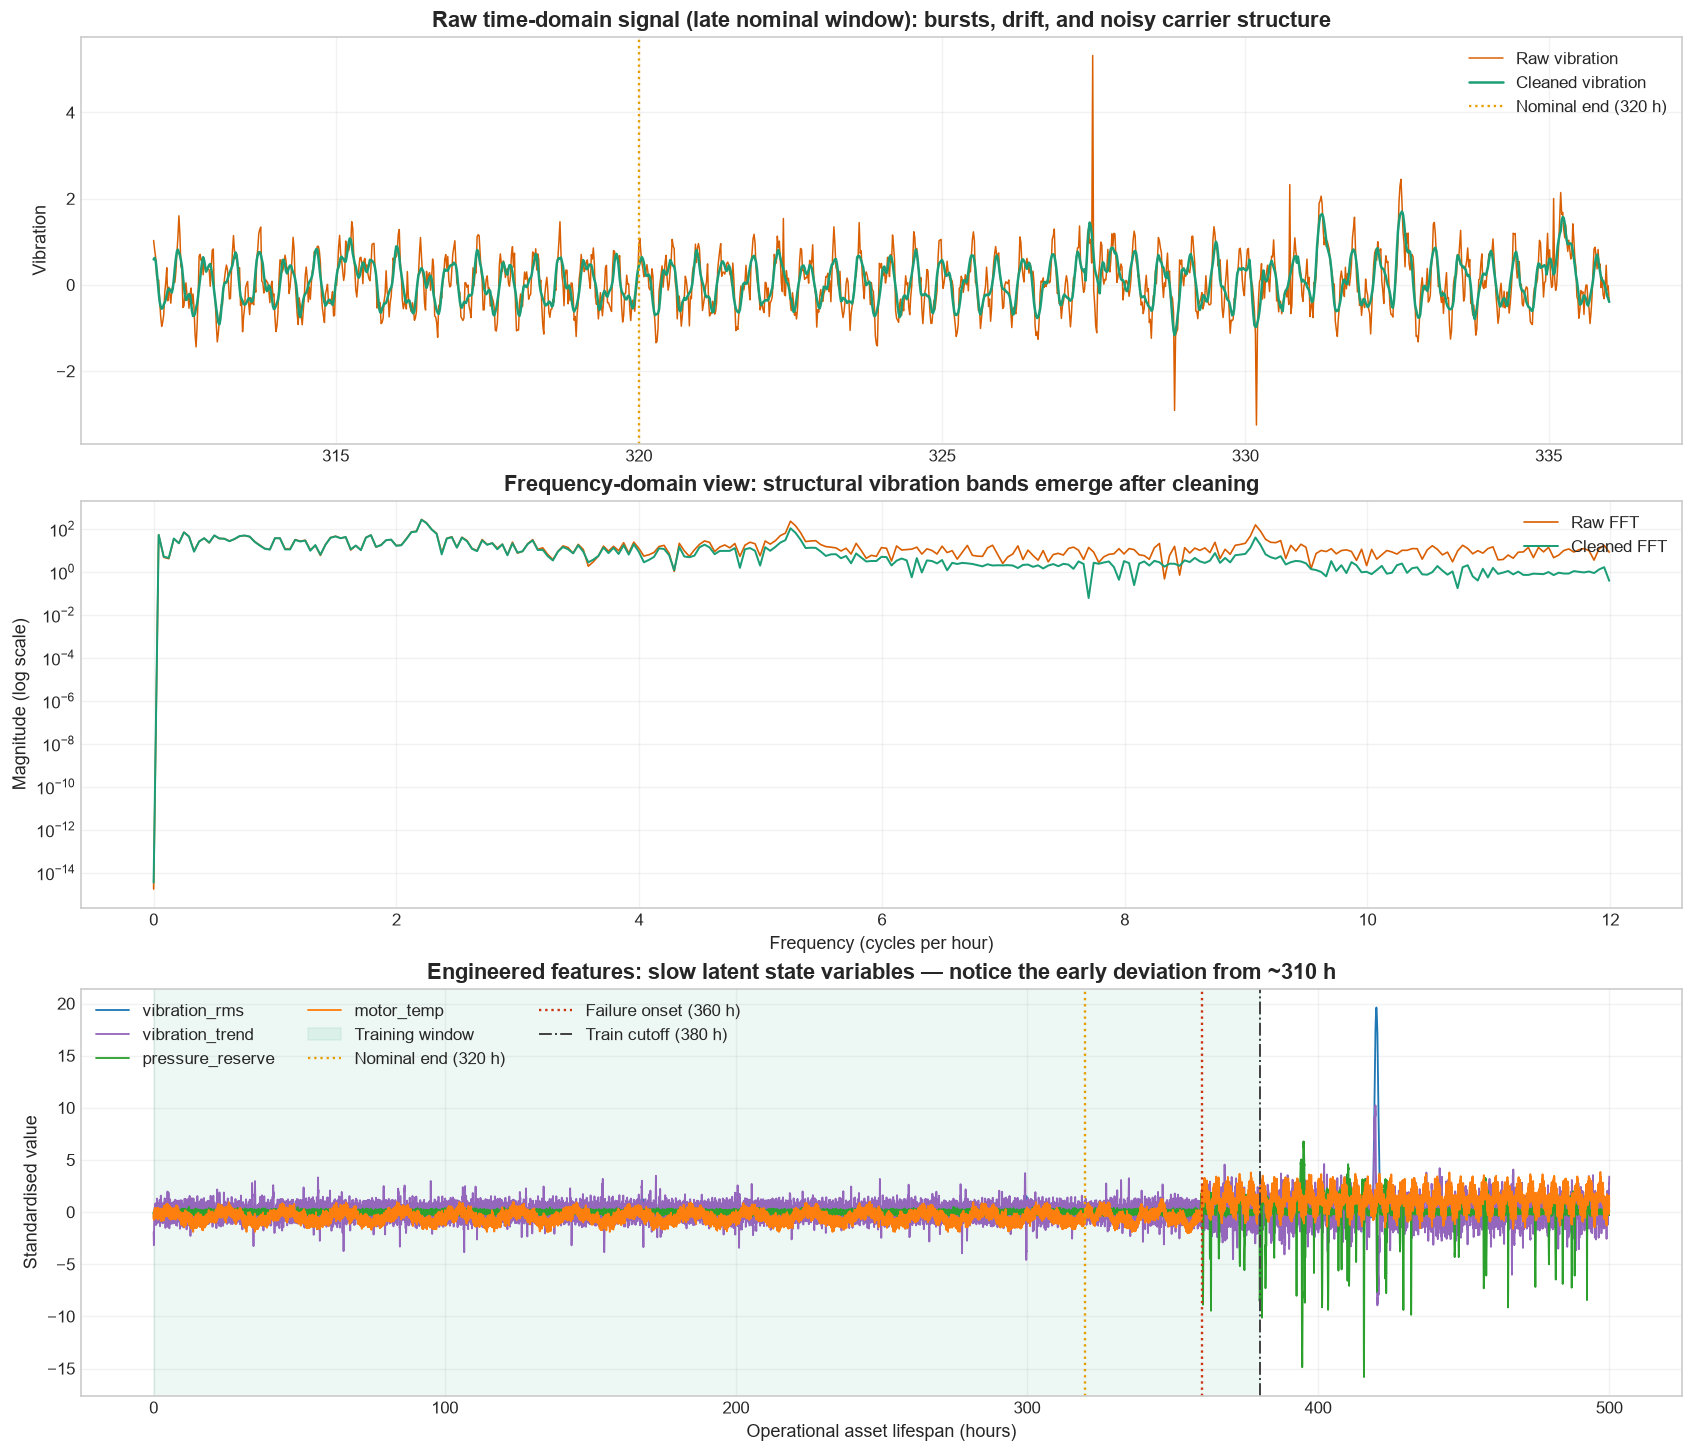

In [4]:
window_df = working_df[(working_df['time_hours'] >= 312) & (working_df['time_hours'] <= 336)].copy()
dt_hours = float(working_df['time_hours'].iloc[1] - working_df['time_hours'].iloc[0])
freq = np.fft.rfftfreq(len(window_df), d=dt_hours)
raw_fft = np.abs(np.fft.rfft(window_df['raw_vibration'].to_numpy() - window_df['raw_vibration'].mean()))
clean_fft = np.abs(np.fft.rfft(window_df['cleaned_vibration'].to_numpy() - window_df['cleaned_vibration'].mean()))
fft_mask = freq <= 12.0

feature_frame = working_df[['vibration_rms', 'vibration_trend', 'pressure_reserve', 'motor_temp']].copy()
feature_z = (feature_frame - feature_frame.mean()) / feature_frame.std(ddof=0)
train_mask = working_df['suggested_split'] == 'train'
train_start = working_df.loc[train_mask, 'time_hours'].min()
train_end = working_df.loc[train_mask, 'time_hours'].max()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), constrained_layout=True)

axes[0].plot(window_df['time_hours'], window_df['raw_vibration'], color='#d95f02', linewidth=0.9, label='Raw vibration')
axes[0].plot(window_df['time_hours'], window_df['cleaned_vibration'], color='#1b9e77', linewidth=1.5, label='Cleaned vibration')
axes[0].axvline(x=NOMINAL_END_H, color='#e69f00', linestyle=':', linewidth=1.4, label='Nominal end (320 h)')
axes[0].set_title('Raw time-domain signal (late nominal window): bursts, drift, and noisy carrier structure')
axes[0].set_ylabel('Vibration')
axes[0].legend(loc='upper right')

axes[1].semilogy(freq[fft_mask], raw_fft[fft_mask], color='#d95f02', linewidth=1.0, label='Raw FFT')
axes[1].semilogy(freq[fft_mask], clean_fft[fft_mask], color='#1b9e77', linewidth=1.2, label='Cleaned FFT')
axes[1].set_title('Frequency-domain view: structural vibration bands emerge after cleaning')
axes[1].set_xlabel('Frequency (cycles per hour)')
axes[1].set_ylabel('Magnitude (log scale)')
axes[1].legend(loc='upper right')

for feature_name, color in zip(engineered_features, ['#1f77b4', '#9467bd', '#2ca02c', '#ff7f0e']):
    axes[2].plot(working_df['time_hours'], feature_z[feature_name], linewidth=1.1, color=color, label=feature_name)
axes[2].axvspan(train_start, train_end, color='#1b9e77', alpha=0.08, label='Training window')
add_regime_lines(axes[2], legend=False)
axes[2].legend(loc='upper left', ncols=3)
axes[2].set_title('Engineered features: slow latent state variables — notice the early deviation from ~310 h')
axes[2].set_xlabel('Operational asset lifespan (hours)')
axes[2].set_ylabel('Standardised value')

plt.show()

## Raw Features versus Engineered Features — and the Split Trap

Two Random Forest models are trained on identical data with identical algorithm settings. The only difference is which columns they receive.

But there is a second story hidden in this section: **how you split the data changes what the score means**. Most tutorials shuffle rows before splitting. For time-series sensor data that is wrong — it lets future failure readings leak into the training set, so the "test" set is no longer truly unseen.

We show both splits side by side:
- **Shuffled split** — the standard tutorial approach; scores look good for both models.
- **Chronological split** — train on the past (0–380 h), test on the future (380–500 h); this is what deployment actually demands.

Feature engineering dominates in both cases. But the honest split shows by how much — and exposes how little the raw-feature model can actually do when it hasn't seen the failure regime before.

In [5]:
model_df = working_df.dropna(subset=['pump_efficiency']).copy()

# ── Shuffled split ─── the way most tutorials show it (and why it misleads) ──────
train_shuf, test_shuf = train_test_split(model_df, test_size=0.3, random_state=42, shuffle=True)

rf_raw_shuf = RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)
rf_raw_shuf.fit(train_shuf[raw_features], train_shuf['pump_efficiency'])
r2_raw_shuf = r2_score(test_shuf['pump_efficiency'], rf_raw_shuf.predict(test_shuf[raw_features]))

rf_eng_shuf = RandomForestRegressor(n_estimators=160, random_state=42, n_jobs=-1)
rf_eng_shuf.fit(train_shuf[engineered_features], train_shuf['pump_efficiency'])
r2_eng_shuf = r2_score(test_shuf['pump_efficiency'], rf_eng_shuf.predict(test_shuf[engineered_features]))

# ── Chronological split ── train on past, test on future (deployment reality) ────
train_df = model_df[model_df['suggested_split'] == 'train'].copy()
test_df  = model_df[model_df['suggested_split'] == 'test'].copy()

baseline_model = RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)
baseline_model.fit(train_df[raw_features], train_df['pump_efficiency'])
baseline_predictions = baseline_model.predict(test_df[raw_features])
baseline_r2 = r2_score(test_df['pump_efficiency'], baseline_predictions)

engineered_model = RandomForestRegressor(n_estimators=160, random_state=42, n_jobs=-1)
engineered_model.fit(train_df[engineered_features], train_df['pump_efficiency'])
engineered_predictions = engineered_model.predict(test_df[engineered_features])
engineered_r2 = r2_score(test_df['pump_efficiency'], engineered_predictions)

print("Shuffled split  (leaks future failure data into training):")
print(f"  Raw-feature R²:        {r2_raw_shuf:.3f}   ← deceptively good")
print(f"  Engineered-feature R²: {r2_eng_shuf:.3f}")
print()
print("Chronological split  (train on past 0–380 h, test on future 380–500 h):")
print(f"  Raw-feature R²:        {baseline_r2:.3f}   ← reality check")
print(f"  Engineered-feature R²: {engineered_r2:.3f}")
print()
print(f"Feature engineering advantage (chronological): {engineered_r2 - baseline_r2:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), constrained_layout=True)

bars0 = axes[0].bar(['Raw\nfeatures', 'Engineered\nfeatures'], [r2_raw_shuf, r2_eng_shuf],
                    color=['#bbbbbb', '#888888'], width=0.55)
axes[0].set_ylim(-0.35, 1.05)
axes[0].set_ylabel('R²')
axes[0].set_title('Shuffled split\n(future data leaks into training — artificially optimistic)')
for bar in bars0:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h + 0.02, f'{h:.3f}', ha='center', va='bottom', fontsize=11)

bars1 = axes[1].bar(['Raw\nfeatures', 'Engineered\nfeatures'], [baseline_r2, engineered_r2],
                    color=['#d95f02', '#1b9e77'], width=0.55)
axes[1].set_ylim(-0.35, 1.05)
axes[1].set_ylabel('R²')
axes[1].set_title('Chronological split\n(train on past, test on future — deployment-realistic)')
for bar in bars1:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, h + 0.02, f'{h:.3f}', ha='center', va='bottom', fontsize=11)

fig.suptitle('Feature engineering dominates in both cases — but the split determines what the score means', fontsize=11, weight='bold')
plt.show()

Shuffled split  (leaks future failure data into training):
  Raw-feature R²:        -0.221   ← deceptively good
  Engineered-feature R²: 0.817

Chronological split  (train on past 0–380 h, test on future 380–500 h):
  Raw-feature R²:        -159.429   ← reality check
  Engineered-feature R²: -69.900

Feature engineering advantage (chronological): +89.530


c:\Users\hp\OneDrive - University of Southampton\Year 3\2 DCE\DCE Code\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


### The split trap — why the shuffled scores are misleading

When rows are shuffled before splitting, future failure-regime readings end up in the training set. The model effectively memorises what failure looks like *before* being asked to predict it. The test set is no longer unseen — it is just more of the same distribution.

The chronological split removes that illusion. Training sees only hours 0–380; the test set is hours 380–500, the part of the lifespan the model has never encountered. Two things become clear:

- **Both scores drop** when the split is honest. The task is genuinely harder than the shuffled score suggests.
- **The raw-feature model approaches zero usefulness** on the chronological split — the single raw vibration reading carries almost no information about what will happen next, once the machine leaves the operating regime it was trained on.
- **The engineered model survives** because the physical state features (`vibration_rms`, `pressure_reserve`, etc.) encode *why* the machine is degrading, not just *what* the last sensor reading was.

This is the core argument for feature engineering: not just better R², but R² that holds up when it matters.

## Prediction Diagnostics

These two plots show what the models actually produce, point by point, on the chronological test set (hours 380–500 — the future the models never saw during training).

The **left panel** maps predicted efficiency against actual. A perfect model would lie on the dashed diagonal. Notice how the raw-feature baseline is a cloud with little diagonal structure, while the engineered model clusters much closer to the ideal line.

The **right panel** shows the engineered model's residuals over time.

**What to notice on the right:** residuals are small and symmetric through the early test window. As the pump approaches and passes the bearing seizure at hour 420, the residuals grow and become structured — the model is extrapolating beyond what it was trained on, and the errors increase in magnitude. This is the warning signal a monitoring system would need to act on.

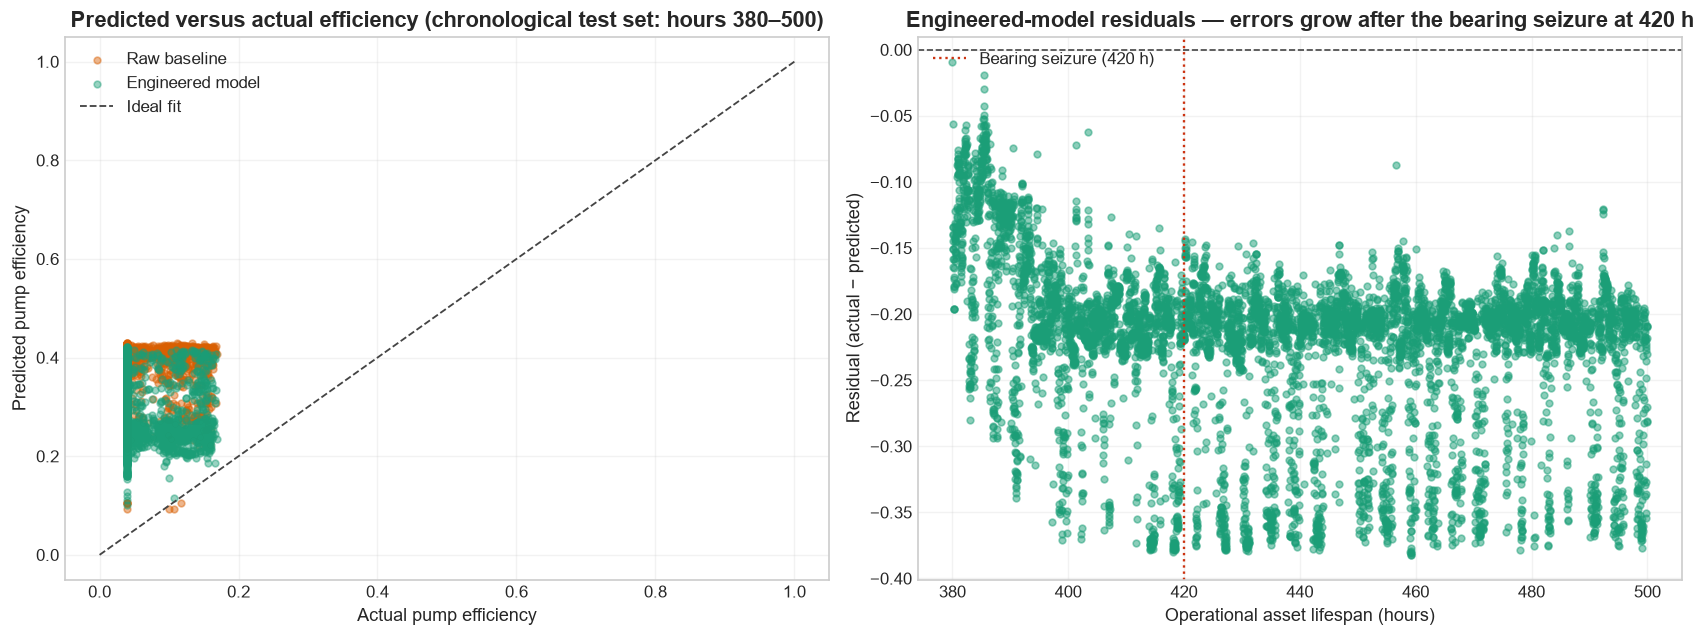

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), constrained_layout=True)

axes[0].scatter(test_df['pump_efficiency'], baseline_predictions, s=16, alpha=0.45, color='#d95f02', label='Raw baseline')
axes[0].scatter(test_df['pump_efficiency'], engineered_predictions, s=16, alpha=0.45, color='#1b9e77', label='Engineered model')
axes[0].plot([0, 1], [0, 1], color='#444444', linestyle='--', linewidth=1.1, label='Ideal fit')
axes[0].set_title('Predicted versus actual efficiency (chronological test set: hours 380–500)')
axes[0].set_xlabel('Actual pump efficiency')
axes[0].set_ylabel('Predicted pump efficiency')
axes[0].legend(loc='upper left')

residuals = test_df['pump_efficiency'].to_numpy() - engineered_predictions
axes[1].scatter(test_df['time_hours'], residuals, s=16, alpha=0.5, color='#1b9e77')
axes[1].axhline(0.0, color='#444444', linestyle='--', linewidth=1.0)
axes[1].axvline(x=420, color='#cc3311', linestyle=':', linewidth=1.4, label='Bearing seizure (420 h)')
axes[1].set_title('Engineered-model residuals — errors grow after the bearing seizure at 420 h')
axes[1].set_xlabel('Operational asset lifespan (hours)')
axes[1].set_ylabel('Residual (actual − predicted)')
axes[1].legend(loc='upper left')

plt.show()

## Model Degradation and Confidence Breakdown

The raw-feature model was trained only on data from hours 0–380. Here we ask it to predict across the full 500-hour lifespan and overlay the individual tree predictions to reveal disagreement.

Inside the training window the tree ensemble broadly agrees — the spread between individual trees is narrow. The moment the pump crosses into the failure regime (hour 360) and particularly after the bearing seizure at hour 420, the trees diverge dramatically: each tree memorised different nominal operating patterns, and none of them saw this operating point before. That divergence is the model's uncertainty signal.

**Key insight:** the model does not know it is wrong. It keeps producing a number. The spread between trees is the only warning that the prediction should not be trusted. A system that only reports the mean prediction would silently deliver a confident wrong answer to the operator.

We also apply domain-knowledge hard limits (`enforce_physical_limits`) — when pressure drops severely below the local baseline (cavitation), efficiency *cannot* remain high regardless of what the model predicts.

c:\Users\hp\OneDrive - University of Southampton\Year 3\2 DCE\DCE Code\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\hp\OneDrive - University of Southampton\Year 3\2 DCE\DCE Code\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\hp\OneDrive - University of Southampton\Year 3\2 DCE\DCE Code\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\hp\OneDrive - University of Southampton\Year 3\2 DCE\DCE Code\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\hp\OneDrive - University of Southam

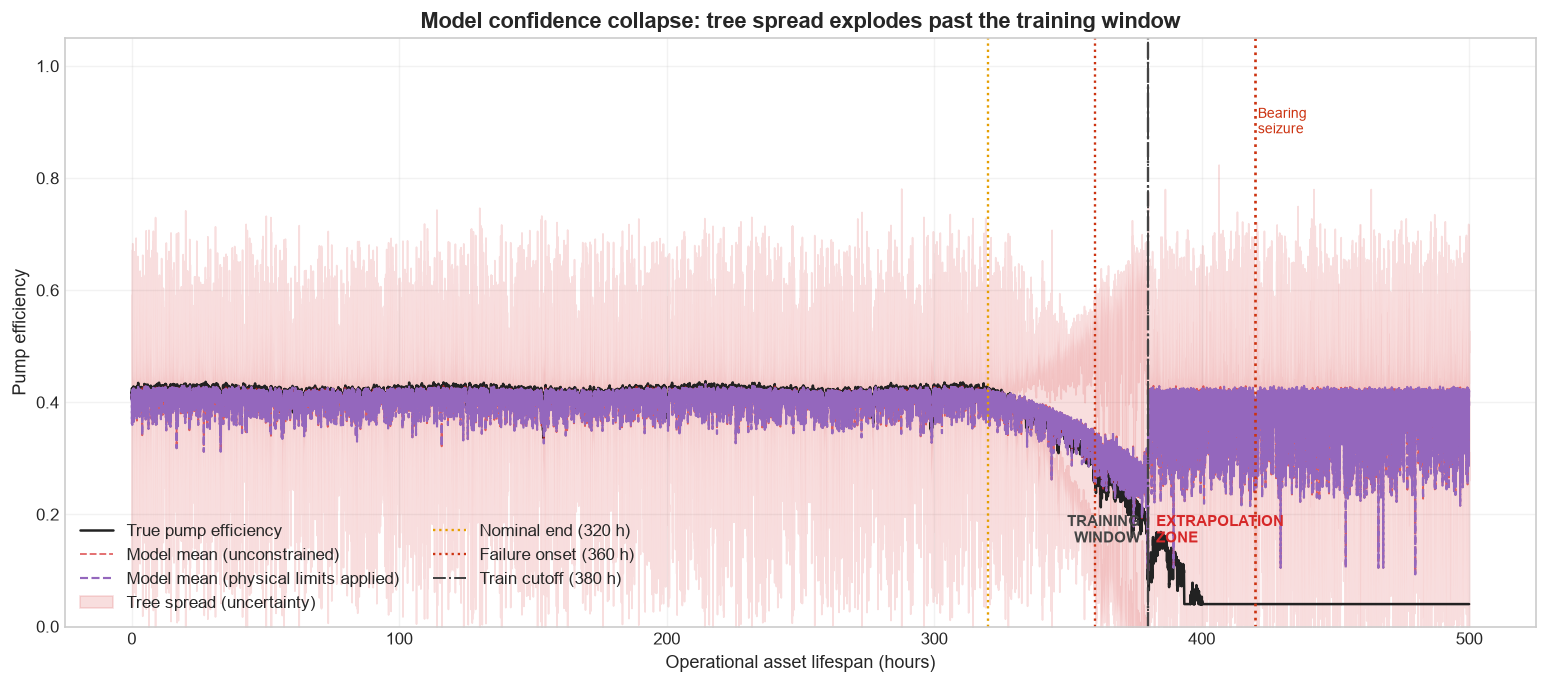

In [7]:
chrono_train = working_df[working_df['suggested_split'] == 'train'].copy()
extrapolation_model = RandomForestRegressor(n_estimators=180, random_state=42, n_jobs=-1)
extrapolation_model.fit(chrono_train[raw_features], chrono_train['pump_efficiency'])

all_tree_runs = np.stack([tree.predict(working_df[raw_features]) for tree in extrapolation_model.estimators_], axis=0)
mean_pred = all_tree_runs.mean(axis=0)
std_pred = all_tree_runs.std(axis=0)

# Apply domain-knowledge hard limits: severe pressure deficit means efficiency cannot stay high
mean_pred_bounded = enforce_physical_limits(mean_pred, working_df)

fig, ax = plt.subplots(figsize=(13, 5.8))
ax.plot(working_df['time_hours'], working_df['pump_efficiency'], color='#222222', linewidth=1.5, label='True pump efficiency')
ax.plot(working_df['time_hours'], mean_pred, color='#d62728', linestyle='--', linewidth=1.1, alpha=0.7, label='Model mean (unconstrained)')
ax.plot(working_df['time_hours'], mean_pred_bounded, color='#9467bd', linestyle='--', linewidth=1.3, label='Model mean (physical limits applied)')
ax.fill_between(working_df['time_hours'], mean_pred - 3.5 * std_pred, mean_pred + 3.5 * std_pred, color='#d62728', alpha=0.15, label='Tree spread (uncertainty)')

cutoff_hour = chrono_train['time_hours'].max()
ax.axvline(x=cutoff_hour, color='#444444', linestyle='-.', linewidth=1.4)
ax.text(cutoff_hour - 3, 0.15, 'TRAINING\nWINDOW', ha='right', color='#444444', weight='bold', fontsize=9)
ax.text(cutoff_hour + 3, 0.15, 'EXTRAPOLATION\nZONE', ha='left', color='#d62728', weight='bold', fontsize=9)

add_regime_lines(ax, legend=False)
ax.axvline(x=420, color='#cc3311', linestyle=':', linewidth=1.6)
ax.text(421, 0.88, 'Bearing\nseizure', color='#cc3311', fontsize=8.5)

ax.set_ylim(0.0, 1.05)
ax.set_xlabel('Operational asset lifespan (hours)')
ax.set_ylabel('Pump efficiency')
ax.set_title('Model confidence collapse: tree spread explodes past the training window')
ax.legend(loc='lower left', ncols=2)
plt.tight_layout()
plt.show()

## Gaussian Process Uncertainty in an Extreme Thermal Slice

A Random Forest expresses uncertainty through tree disagreement — a useful proxy, but it has no principled probabilistic interpretation. A **Gaussian Process (GPR)** models uncertainty directly: the posterior variance grows as the query point moves away from the training data.

We sweep motor temperature along a slice from the observed training range out into a regime the model has never seen (>70 °C). The shaded band shows ±2σ. Inside the training temperature range the band is narrow — the model has seen examples there and has learned the relationship. Outside it, the band expands to cover most of the [0, 1] efficiency range.

**What to notice:** the GPR mean prediction keeps extrapolating beyond the training boundary, but the uncertainty band correctly tells you that the model does not know what is happening at 85–95 °C. In a safety-critical system, that expanding uncertainty band should trigger a human review, not an automated action based on the mean alone.

This is fundamentally different from the Random Forest: the GPR is calibrated to say "I don't know" in regions where it lacks data.

c:\Users\hp\OneDrive - University of Southampton\Year 3\2 DCE\DCE Code\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 50.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


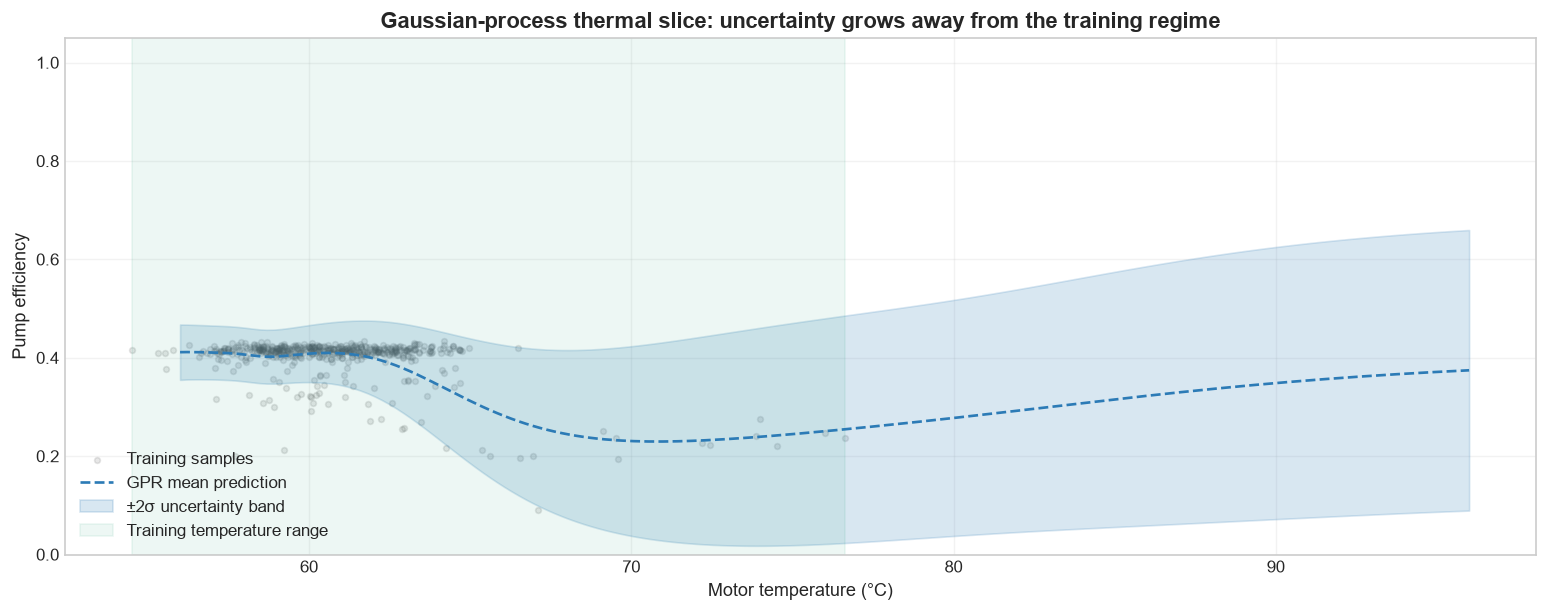

In [8]:
gp_train = chrono_train[['vibration_rms', 'vibration_trend', 'pressure_reserve', 'motor_temp', 'pump_efficiency']].sample(n=min(500, len(chrono_train)), random_state=42).sort_values('motor_temp').copy()
gpr_features_train = gp_train[['vibration_rms', 'vibration_trend', 'pressure_reserve', 'motor_temp']].copy()
gpr_scaler = StandardScaler()
gpr_train_scaled = gpr_scaler.fit_transform(gpr_features_train)

kernel = ConstantKernel(1.0, (0.01, 100.0)) * Matern(length_scale=np.ones(gpr_features_train.shape[1]), length_scale_bounds=(0.01, 50.0), nu=1.5) + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-6, 0.5))
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True, n_restarts_optimizer=2, random_state=42)
gpr.fit(gpr_train_scaled, gp_train['pump_efficiency'])

slice_anchor = gpr_features_train.median()
thermal_axis = np.linspace(56.0, 96.0, 180)
gpr_slice = pd.DataFrame({
    'vibration_rms': np.full(thermal_axis.size, slice_anchor['vibration_rms']),
    'vibration_trend': np.linspace(slice_anchor['vibration_trend'], slice_anchor['vibration_trend'] + 0.03, thermal_axis.size),
    'pressure_reserve': np.linspace(slice_anchor['pressure_reserve'], slice_anchor['pressure_reserve'] - 7.5, thermal_axis.size),
    'motor_temp': thermal_axis,
})
gpr_mean, gpr_std = gpr.predict(gpr_scaler.transform(gpr_slice), return_std=True)
training_temp_range = (gp_train['motor_temp'].min(), gp_train['motor_temp'].max())

fig, ax = plt.subplots(figsize=(13, 5.2))
ax.scatter(gp_train['motor_temp'], gp_train['pump_efficiency'], s=12, alpha=0.14, color='#555555', label='Training samples')
ax.plot(thermal_axis, gpr_mean, color='#2c7bb6', linewidth=1.6, linestyle='--', label='GPR mean prediction')
ax.fill_between(thermal_axis, np.clip(gpr_mean - 2 * gpr_std, 0, 1), np.clip(gpr_mean + 2 * gpr_std, 0, 1), color='#2c7bb6', alpha=0.18, label='±2σ uncertainty band')
ax.axvspan(training_temp_range[0], training_temp_range[1], color='#1b9e77', alpha=0.08, label='Training temperature range')
ax.set_ylim(0.0, 1.05)
ax.set_xlabel('Motor temperature (°C)')
ax.set_ylabel('Pump efficiency')
ax.set_title('Gaussian-process thermal slice: uncertainty grows away from the training regime')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

## Forensic Audit with SHAP

SHAP (SHapley Additive exPlanations) uses Shapley values from cooperative game theory to fairly allocate the model's prediction to individual features. For each data point, every feature receives a credit or blame score that sums to the difference between that prediction and the model's average prediction.

The **summary plot** shows which features matter most across the entire test set, and in which direction — red means a high feature value pushed the prediction up, blue means it pushed it down.

The **force plot** below diagnoses a single specific prediction: the worst-efficiency data point in the test set.

**What to notice on the force plot:** `vibration_rms` and `pressure_reserve` push the efficiency prediction strongly downward. This is not a statistical artefact — it directly corresponds to an elevated bearing-load energy state combined with a significant pressure deficit. A maintenance engineer reading this output knows immediately: *inspect the bearing and check for upstream cavitation*. 

SHAP converts a black-box number into a maintenance action item.

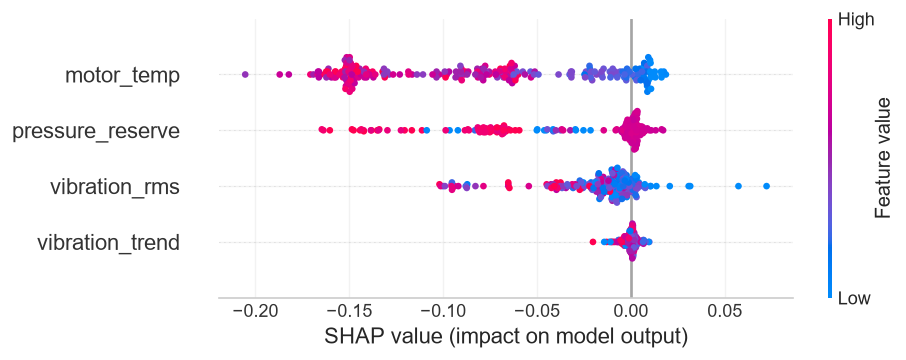

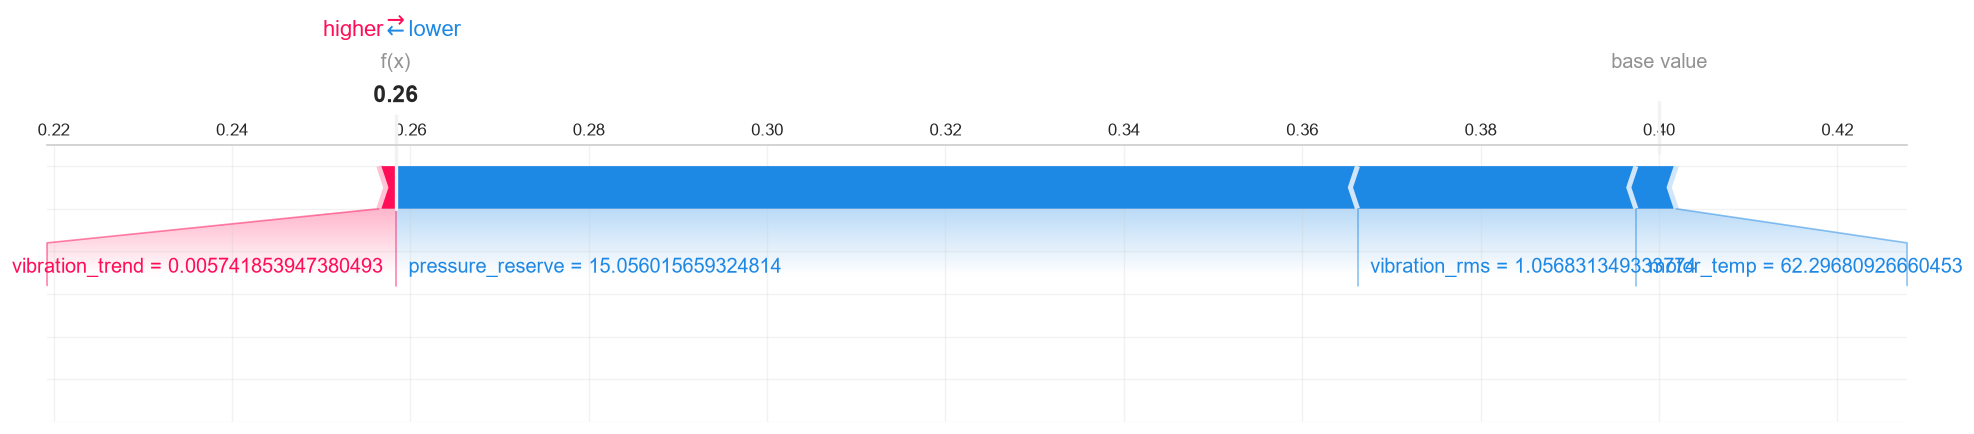

In [9]:
shap_sample = test_df[engineered_features].sample(n=min(240, len(test_df)), random_state=42)
shap_explainer = shap.TreeExplainer(engineered_model)
shap_values = shap_explainer.shap_values(shap_sample)

shap.summary_plot(shap_values, shap_sample, show=True)

anomalous_row = test_df.sort_values('pump_efficiency').head(1)[engineered_features]
shap_force = shap_explainer.shap_values(anomalous_row)
shap.force_plot(shap_explainer.expected_value, shap_force[0], anomalous_row.iloc[0], matplotlib=True, show=True)

### From SHAP values to a maintenance action

The force plot above shows *why* the model predicted that specific low-efficiency reading. Reading it as an engineer:

| Feature with high SHAP impact | Physical interpretation | Maintenance action |
|---|---|---|
| `vibration_rms` (high, pushes down) | Elevated bearing-load energy; mechanical wear accumulating | Inspect and grease or replace bearings |
| `pressure_reserve` (negative, pushes down) | Pressure repeatedly dropping below local baseline; intermittent cavitation | Check upstream valve and impeller for cavitation damage |
| `motor_temp` (elevated) | Thermal accumulation; possible winding degradation or inadequate cooling | Inspect cooling fins and check motor winding resistance |
| `vibration_trend` (rising) | Energy envelope is increasing over time; fault is actively progressing | Schedule shutdown before next maintenance window |

This is what explainability means in practice. Not "the model gives a confidence score" — but "the model tells you which physical system is failing and what to do about it."

A prediction without an explanation is a number. A prediction *with* a SHAP breakdown is a maintenance report.

## Summary

| Stage | What we showed | The lesson |
|---|---|---|
| Raw signal | Noisy, carrier-dominated time series | Sensor data is rarely usable as-is |
| Cleaning | Dropout fill, SG filter, drift correction | Domain knowledge unlocks the signal before any ML starts |
| Feature engineering | RMS, trend, pressure reserve, temp | Physics-aware features change R² more than algorithm choice does |
| Split strategy | Shuffled vs chronological | The evaluation strategy determines what the score *means* |
| Model degradation | RF tree spread beyond the training window | Models do not know they are wrong — spread is the only warning |
| Uncertainty (GPR) | Posterior variance grows outside training data | A prediction without a confidence bound is dangerous in safety-critical systems |
| SHAP | Feature attribution on the worst-case prediction | Explainability converts a model output into a maintenance action |

The model is a tool. Understanding its limits — and communicating them honestly — is the engineering skill.